In [2]:

import numpy as np
import matplotlib.pyplot as plt
 
np.random.seed(0)          # same points on every run
X = np.random.rand(10, 2)   # 10 points, 2 coordinates each
 
print(X)
print("Shape of X:", X.shape)


[[0.5488135  0.71518937]
 [0.60276338 0.54488318]
 [0.4236548  0.64589411]
 [0.43758721 0.891773  ]
 [0.96366276 0.38344152]
 [0.79172504 0.52889492]
 [0.56804456 0.92559664]
 [0.07103606 0.0871293 ]
 [0.0202184  0.83261985]
 [0.77815675 0.87001215]]
Shape of X: (10, 2)


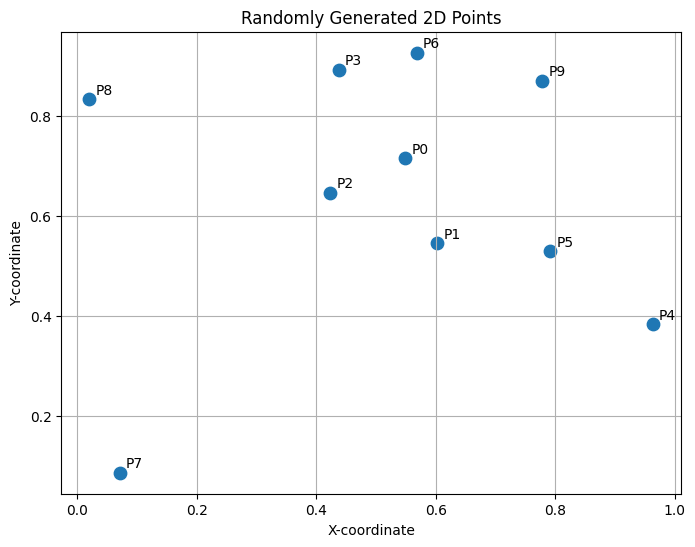

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=80)
for i, (x, y) in enumerate(X):
    plt.text(x + 0.01, y + 0.01, f"P{i}")   # label each point
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("Randomly Generated 2D Points")
plt.grid(True)
plt.show()


In [4]:
D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
print(D2.shape)      # (10, 10)


(10, 10)


In [5]:
# (a) coordinate differences for every pair of points
diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
print("Coordinate differences:", diff.shape)
 
# (b) square each difference
sq_diff = diff ** 2
print("Squared differences:", sq_diff.shape)
 
# (c) add the x and y parts together
D2_steps = np.sum(sq_diff, axis=2)
print("Summed squared distances:", D2_steps.shape)
 
print(np.allclose(D2, D2_steps))   # both routes agree


Coordinate differences: (10, 10, 2)
Squared differences: (10, 10, 2)
Summed squared distances: (10, 10)
True


In [6]:
diagonal = np.diag(D2)
print("Diagonal:", diagonal)
print("All zeros?", np.allclose(diagonal, 0))


Diagonal: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
All zeros? True


In [18]:
order = np.argsort(D2, axis=1)    # each row: point indices from nearest to farthest
print(order)
print("First column:", order[:, 0])


[[0 2 1 3 6 9 5 4 8 7]
 [1 0 5 2 9 6 3 4 8 7]
 [2 0 1 3 6 5 9 8 4 7]
 [3 6 0 2 9 1 8 5 4 7]
 [4 5 1 9 0 2 6 3 7 8]
 [5 1 4 0 9 2 6 3 8 7]
 [6 3 0 9 2 1 5 8 4 7]
 [7 2 1 8 0 5 3 4 6 9]
 [8 3 2 0 6 1 7 9 5 4]
 [9 6 0 3 5 1 2 4 8 7]]
First column: [0 1 2 3 4 5 6 7 8 9]


In [19]:
K = 2
nearest_argsort = order[:, 1:K + 1]   # skip column 0 (the point itself)
print(nearest_argsort)


[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]


In [20]:
# indices of the K+1 smallest distances in each row (unordered)
cand = np.argpartition(D2, K + 1, axis=1)[:, :K + 1]
 
# distances of those candidates, then sort just these 3 per row
cand_d = np.take_along_axis(D2, cand, axis=1)
local = np.argsort(cand_d, axis=1)
cand_sorted = np.take_along_axis(cand, local, axis=1)
 
nearest = cand_sorted[:, 1:K + 1]      # drop the point itself
print(nearest)
print("Same as argsort result?", np.array_equal(nearest, nearest_argsort))


[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]
Same as argsort result? True


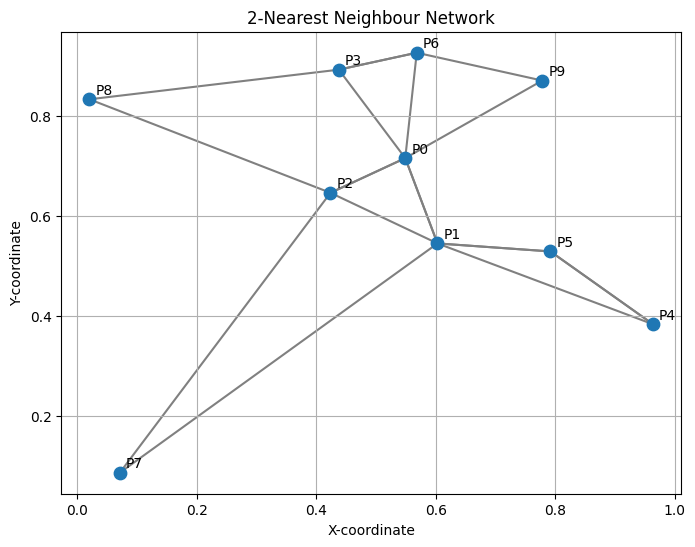

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=80, zorder=3)
for i in range(len(X)):
    plt.text(X[i, 0] + 0.01, X[i, 1] + 0.01, f"P{i}")
    for j in nearest[i]:                       # its two nearest neighbours
        plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], color="gray", zorder=1)
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("2-Nearest Neighbour Network")
plt.grid(True)
plt.show()


In [26]:
def loop_neighbours(X, K=2):
    N = len(X)
    dist = np.zeros((N, N))
    for i in range(N):                    # every pair, one at a time
        for j in range(N):
            d = X[i] - X[j]
            dist[i, j] = np.sum(d ** 2)
    result = np.zeros((N, K), dtype=int)
    for i in range(N):                    # sort one row at a time
        result[i] = np.argsort(dist[i])[1:K + 1]
    return result



In [25]:
def vector_neighbours(X, K=2):
    D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
    cand = np.argpartition(D2, K + 1, axis=1)[:, :K + 1]
    cand_d = np.take_along_axis(D2, cand, axis=1)
    local = np.argsort(cand_d, axis=1)
    return np.take_along_axis(cand, local, axis=1)[:, 1:K + 1]


In [ ]:
for n in [100, 1000, 5000]:
    Xn = np.random.rand(n, 2)
    %timeit vector_neighbours(Xn)
    %timeit loop_neighbours(Xn)


2.73 ms ± 239 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
300 ms ± 24.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
204 ms ± 26.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
from sklearn.neighbors import KDTree
import numpy as np
 
np.random.seed(0)
Xb = np.random.rand(1000, 2)
 
numpy_result = vector_neighbours(Xb)      # brute-force NumPy answer
 
tree = KDTree(Xb)                          # build the tree
_, idx = tree.query(Xb, k=3)               # k=3: the point itself + 2 neighbours
tree_result = idx[:, 1:]                   # drop the point itself
 
print("Same neighbours?", np.array_equal(numpy_result, tree_result))
 
%timeit vector_neighbours(Xb)
%timeit KDTree(Xb).query(Xb, k=3)
